<a href="https://colab.research.google.com/github/FlemingJohn/AI-Agents/blob/main/Graph_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install langgraph

In [45]:
from langgraph.graph import START, END, StateGraph

In [46]:
from typing_extensions import TypedDict,Literal
import random
class JourneyState(TypedDict):
  current_location: str


In [47]:
def coimbatore():
  print("Starting journey from the coimbatore")
  return {"current_location": "Departed from Coimbatore"}

def chennai():
  print("Arrived at chenai")
  return {"current_location": "Visited Chennai"}

def salem():
  print("Arrived at salem")
  return {"current_location": "salem"}

In [48]:
def route(state: JourneyState) -> Literal["chennai", "salem"]:
  print(f"Deciding route LastUpdate: {state['current_location']}")
  if random.random() < 0.5:
    print("--> Route Selected: Chennai")
    return "chennai"
  else:
    print("--> Route Selected: Salem")
    return "salem"



In [49]:
builder = StateGraph(JourneyState)


In [50]:
builder.add_node("coimbatore",coimbatore)
builder.add_node("chennai",chennai)
builder.add_node("salem",salem)

In [24]:
builder.add_edge(START, "coimbatore")


In [25]:
builder.add_conditional_edges("coimbatore",route)


In [38]:
builder.add_edge("chennai",END)
builder.add_edge("salem",END)

In [42]:
graph = builder.compile()

In [33]:
from IPython.display import Image, display

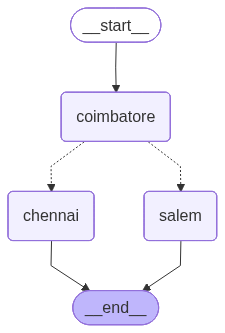

In [44]:
display(Image(graph.get_graph().draw_mermaid_png()))